# Comparative Analysis
## Lucas-Kanade vs Farnebäck vs RAFT

---

### What This Notebook Does
We systematically compare all three methods under identical conditions and write findings.


### The Research Question
> *"How do classical and deep learning optical flow methods compare on real autonomous driving scenes in terms of accuracy, speed, and failure modes?"*

---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Verify KITTI DataSet
import os

KITTI_ROOT = '/content/drive/MyDrive/OpticalFlow/KITTI'

if os.path.exists(KITTI_ROOT):
    print('KITTI folder found at:', KITTI_ROOT)
    print('Contents:', os.listdir(KITTI_ROOT)[:10])
else:
    print('KITTI folder NOT found.')


Mounted at /content/drive
KITTI folder found at: /content/drive/MyDrive/OpticalFlow/KITTI
Contents: ['training']


In [2]:
# INSTALL RAFT
import os

# Base directory — everything lives here
OPTFLOW_DIR = '/content/drive/MyDrive/OpticalFlow'
RAFT_DIR    = f'{OPTFLOW_DIR}/RAFT'
RAFT_LOCAL  = '/content/RAFT'

# Clone official RAFT repository (Princeton) to Drive for persistence
if not os.path.exists(RAFT_DIR):
    print("Cloning RAFT repository...")
    os.system(f'git clone https://github.com/princeton-vl/RAFT.git {RAFT_DIR}')
    print("RAFT cloned to Drive")
else:
    print("RAFT already exists on Drive")

# Symlink Drive copy to /content/RAFT so RAFT imports work correctly
if not os.path.exists(RAFT_LOCAL):
    os.system(f'ln -s {RAFT_DIR} {RAFT_LOCAL}')
    print("Symlink created")

# Install dependencies
os.system('pip install -q einops timm')
print("Dependencies installed")

RAFT already exists on Drive
Symlink created
Dependencies installed


In [3]:
# DOWNLOAD RAFT PRETRAINED WEIGHTS
import os

# Weights stored in Drive so they persist across sessions
WEIGHTS_DIR  = f'{OPTFLOW_DIR}/RAFT/models'
WEIGHTS_PATH = f'{WEIGHTS_DIR}/raft-kitti.pth'
FALLBACK_PATH = f'{WEIGHTS_DIR}/raft-things.pth'

# Local symlinked path : RAFT code expects weights here
LOCAL_WEIGHTS_DIR = '/content/RAFT/models'

os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(LOCAL_WEIGHTS_DIR, exist_ok=True)

# Install gdown for downloading from Google Drive
os.system('pip install -q gdown')

if not os.path.exists(WEIGHTS_PATH):
    print("Downloading RAFT-KITTI pretrained weights...")

    # Official weights from RAFT authors (Princeton)
    # raft-kitti.pth : fine-tuned on KITTI, best for our evaluation
    os.system(
        f'gdown https://drive.google.com/uc?id=1MqDajR89k-xLV0HIrmJ0k-n8ZpG6_suM '
        f'-O {WEIGHTS_PATH}'
    )

    if os.path.exists(WEIGHTS_PATH):
        size_mb = os.path.getsize(WEIGHTS_PATH) / (1024 * 1024)
        print(f"Downloaded RAFT-KITTI weights ({size_mb:.1f} MB)")
    else:
        # Fallback to raft-things if kitti download fails
        print("KITTI weights download failed — trying raft-things as fallback...")
        os.system(
            f'gdown https://drive.google.com/uc?id=1iHSABMkKDEoW_nCJHg7fYZAqe9oR6CPj '
            f'-O {FALLBACK_PATH}'
        )
        WEIGHTS_PATH = FALLBACK_PATH
        print("Using raft-things.pth as fallback")
else:
    print(f"Weights already downloaded: {WEIGHTS_PATH}")

# Symlink weights to local RAFT directory so RAFT code can find them
LOCAL_WEIGHTS_PATH = f'{LOCAL_WEIGHTS_DIR}/raft-kitti.pth'
if not os.path.exists(LOCAL_WEIGHTS_PATH):
    os.system(f'ln -s {WEIGHTS_PATH} {LOCAL_WEIGHTS_PATH}')

print(f"\nUsing weights: {WEIGHTS_PATH}")

Weights already downloaded: /content/drive/MyDrive/OpticalFlow/RAFT/models/raft-kitti.pth

Using weights: /content/drive/MyDrive/OpticalFlow/RAFT/models/raft-kitti.pth


In [4]:
# IMPORTS
import sys
import os
import numpy as np
import torch
import torch.nn.functional as F
import cv2
import matplotlib.pyplot as plt
import glob
import json
from pathlib import Path

# Add RAFT to Python path so we can import its modules
# RAFT code lives in /content/RAFT/core — Python doesn't know this by default
sys.path.insert(0, '/content/RAFT/core')

# Import RAFT model and utilities
from raft import RAFT
from utils import flow_viz           # RAFT's built-in flow visualization
from utils.utils import InputPadder  # Pads images to be divisible by 8

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device.type == 'cuda':
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found : RAFT will run on CPU (slower)")

%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['figure.dpi'] = 100

print(f"PyTorch version: {torch.__version__}")

Using device: cuda
GPU : Tesla T4
VRAM: 15.6 GB
PyTorch version: 2.11.0+cu128


In [11]:
def load_image(path):
    """Load image from disk and convert BGR -> RGB."""
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def load_kitti_flow(path):

    flow_raw = cv2.imread(path, cv2.IMREAD_ANYDEPTH | cv2.IMREAD_COLOR)
    if flow_raw is None:
        return None, None
    valid = flow_raw[:, :, 0] > 0 # B channel = validity mask
    u = (flow_raw[:, :, 2].astype(np.float32) - 2**15) / 64.0   # R channel = horizontal flow
    v = (flow_raw[:, :, 1].astype(np.float32) - 2**15) / 64.0   # G channel = vertical flow
    return np.stack([u, v], axis=2), valid


def flow_to_hsv(flow):
    """Convert flow field to HSV color visualization (hue=direction, sat=magnitude)."""
    u, v = flow[:, :, 0], flow[:, :, 1]
    magnitude = np.sqrt(u**2 + v**2)
    angle = np.arctan2(v, u)
    hsv = np.zeros((*flow.shape[:2], 3), dtype=np.uint8)
    hsv[:, :, 0] = ((angle + np.pi) / (2 * np.pi) * 180).astype(np.uint8)
    max_mag = magnitude.max()
    if max_mag > 0:
        hsv[:, :, 1] = (magnitude / max_mag * 255).astype(np.uint8)
    hsv[:, :, 2] = 255
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)


def compute_epe(predicted_flow, gt_flow, valid_mask):
    """
    Compute End-Point Error (EPE) : standard optical flow metric.
    EPE = mean Euclidean distance between predicted and GT flow over valid pixels.
    """
    if gt_flow is None or valid_mask is None:
        return None, None
    if predicted_flow.shape[:2] != gt_flow.shape[:2]:
        predicted_flow = cv2.resize(
            predicted_flow, (gt_flow.shape[1], gt_flow.shape[0])
        )
    diff_u = predicted_flow[:, :, 0] - gt_flow[:, :, 0]
    diff_v = predicted_flow[:, :, 1] - gt_flow[:, :, 1]
    epe_map = np.sqrt(diff_u**2 + diff_v**2)
    return float(epe_map[valid_mask].mean()), epe_map


# Lucas-Kanade (sparse -> dense interpolation)

def compute_lucas_kanade_dense(frame1, frame2):
    """Track sparse feature points with LK, then interpolate to dense flow for EPE comparison."""
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_RGB2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_RGB2GRAY)

    p0 = cv2.goodFeaturesToTrack(gray1, maxCorners=1000, qualityLevel=0.3, minDistance=7)
    if p0 is None:
        return np.zeros((*frame1.shape[:2], 2))

    lk_params = dict(winSize=(15, 15), maxLevel=3,
                     criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))
    p1, status, _ = cv2.calcOpticalFlowPyrLK(gray1, gray2, p0, None, **lk_params)

    good_new = p1[status == 1]
    good_old = p0[status == 1]
    vectors = good_new - good_old  # (N, 2) sparse flow vectors
    return good_old, good_new, vectors


# Farnebacks (dense)

def compute_farneback(frame1, frame2):
    """Compute dense optical flow using Farnebacks polynomial expansion method."""
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_RGB2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_RGB2GRAY)
    return cv2.calcOpticalFlowFarneback(gray1, gray2, None, 0.5, 3, 15, 3, 5, 1.2, 0)


#  RAFT (deep learning)

class Args:
    """RAFT configuration object."""
    small           = False
    mixed_precision = False
    alternate_corr  = False
    dropout         = 0

    def __contains__(self, key):
        # Allows 'dropout' in args to work correctly
        return hasattr(self, key)


@torch.no_grad()
def compute_raft_flow(model, frame1, frame2, device, iters=20):
    """Run RAFT inference on an image pair and return dense flow (H, W, 2)."""
    def to_tensor(img):
        return torch.from_numpy(img).permute(2, 0, 1).float().unsqueeze(0).to(device)

    img1, img2 = to_tensor(frame1), to_tensor(frame2)
    padder = InputPadder(img1.shape)
    img1, img2 = padder.pad(img1, img2)
    flow_predictions = model(img1, img2, iters=iters, test_mode=True)
    flow = flow_predictions[-1] if isinstance(flow_predictions, (list, tuple)) else flow_predictions
    return padder.unpad(flow).squeeze(0).cpu().numpy().transpose(1, 2, 0)


# Load RAFT model

WEIGHTS_PATH = '/content/drive/MyDrive/OpticalFlow/RAFT/models/raft-kitti.pth'

raft_model = RAFT(Args())
weights = torch.load(WEIGHTS_PATH, map_location=device)
weights = {k.replace('module.', ''): v for k, v in weights.items()}
raft_model.load_state_dict(weights)
raft_model = raft_model.to(device).eval()
print(f"RAFT loaded: {WEIGHTS_PATH}")


# Load KITTI image pairs

IMAGE_DIR = '/content/drive/MyDrive/OpticalFlow/KITTI/training/colored_0'
FLOW_DIR  = '/content/drive/MyDrive/OpticalFlow/KITTI/training/flow_occ'

frame1_files = sorted(glob.glob(os.path.join(IMAGE_DIR, '*_10.png')))
pairs = [
    (f, f.replace('_10.png', '_11.png'))
    for f in frame1_files
    if os.path.exists(f.replace('_10.png', '_11.png'))
]
print(f"All methods loaded. Evaluating {len(pairs)} pairs.")

RAFT loaded: /content/drive/MyDrive/OpticalFlow/RAFT/models/raft-kitti.pth
All methods loaded. Evaluating 194 pairs.


## Run All Methods

### What Makes a Fair Comparison
- Same image pairs for all methods
- Same evaluation metric (EPE)
- Same KITTI ground truth
- Record timing for each method

In [12]:
import time

# Run all three methods on all pairs and collect results for comparison.
print("Running all methods for comparison...")

all_results = []

for i, (f1_path, f2_path) in enumerate(pairs):
    print(f"\nPair {i+1}/{len(pairs)}: {os.path.basename(f1_path)}")

    frame1 = load_image(f1_path)
    frame2 = load_image(f2_path)

    # Load ground truth flow if available
    gt_flow, valid_mask = None, None
    if FLOW_DIR:
        gt_flow_path = os.path.join(FLOW_DIR, os.path.basename(f1_path))
        if os.path.exists(gt_flow_path):
            gt_flow, valid_mask = load_kitti_flow(gt_flow_path)

    pair_result = {'pair_id': i + 1, 'frame1': frame1, 'frame2': frame2}

    # Lucas-Kanade
    t0 = time.time()
    lk_old, lk_new, lk_vectors = compute_lucas_kanade_dense(frame1, frame2)
    lk_time = time.time() - t0
    lk_magnitudes = np.sqrt(lk_vectors[:, 0]**2 + lk_vectors[:, 1]**2) if lk_vectors is not None else [0]

    pair_result['lk'] = {
        'time': lk_time,
        'mean_magnitude': float(np.mean(lk_magnitudes)),
        'n_points': len(lk_magnitudes),
        'old_pts': lk_old,
        'new_pts': lk_new
    }
    print(f"Lucas-Kanade : {lk_time:.3f}s | tracked {len(lk_magnitudes)} points | mean mag {np.mean(lk_magnitudes):.2f}px")

    # Farneback
    t0 = time.time()
    fb_flow = compute_farneback(frame1, frame2)
    fb_time = time.time() - t0
    fb_epe, fb_epe_map = compute_epe(fb_flow, gt_flow, valid_mask) if gt_flow is not None else (None, None)
    fb_mag = np.sqrt(fb_flow[:, :, 0]**2 + fb_flow[:, :, 1]**2)

    pair_result['farneback'] = {
        'time': fb_time,
        'epe': fb_epe,
        'mean_magnitude': float(fb_mag.mean()),
        'flow': fb_flow,
        'epe_map': fb_epe_map
    }
    epe_str = f"EPE={fb_epe:.2f}px" if fb_epe is not None else "EPE=N/A"
    print(f"  Farneback: {fb_time:.3f}s | {epe_str} | mean mag {fb_mag.mean():.2f}px")

    # RAFT
    t0 = time.time()
    raft_flow = compute_raft_flow(raft_model, frame1, frame2, device)
    raft_time = time.time() - t0
    raft_epe, raft_epe_map = compute_epe(raft_flow, gt_flow, valid_mask) if gt_flow is not None else (None, None)
    raft_mag = np.sqrt(raft_flow[:, :, 0]**2 + raft_flow[:, :, 1]**2)

    pair_result['raft'] = {
        'time': raft_time,
        'epe': raft_epe,
        'mean_magnitude': float(raft_mag.mean()),
        'flow': raft_flow,
        'epe_map': raft_epe_map
    }
    epe_str = f"EPE={raft_epe:.2f}px" if raft_epe is not None else "EPE=N/A"
    print(f" RAFT: {raft_time:.3f}s | {epe_str} | mean mag {raft_mag.mean():.2f}px")

    all_results.append(pair_result)

print("\nAll methods evaluated on all pairs.")

Running all methods for comparison...

Pair 1/194: 000000_10.png
Lucas-Kanade : 0.016s | tracked 191 points | mean mag 14.66px
  Farneback: 0.200s | EPE=34.51px | mean mag 16.45px


/content/RAFT/core/raft.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
/content/RAFT/core/raft.py:110: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
/content/RAFT/core/raft.py:127: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):


 RAFT: 0.433s | EPE=2.76px | mean mag 47.19px

Pair 2/194: 000001_10.png
Lucas-Kanade : 0.010s | tracked 28 points | mean mag 6.74px
  Farneback: 0.212s | EPE=66.27px | mean mag 9.49px
 RAFT: 0.355s | EPE=14.95px | mean mag 75.21px

Pair 3/194: 000002_10.png
Lucas-Kanade : 0.011s | tracked 56 points | mean mag 12.03px
  Farneback: 0.176s | EPE=37.41px | mean mag 9.44px
 RAFT: 0.356s | EPE=5.74px | mean mag 43.61px

Pair 4/194: 000003_10.png
Lucas-Kanade : 0.012s | tracked 80 points | mean mag 14.54px
  Farneback: 0.190s | EPE=15.99px | mean mag 16.40px
 RAFT: 0.357s | EPE=1.17px | mean mag 29.08px

Pair 5/194: 000004_10.png
Lucas-Kanade : 0.010s | tracked 116 points | mean mag 43.56px
  Farneback: 0.132s | EPE=27.98px | mean mag 18.09px
 RAFT: 0.356s | EPE=0.50px | mean mag 45.58px

Pair 6/194: 000005_10.png
Lucas-Kanade : 0.007s | tracked 40 points | mean mag 14.43px
  Farneback: 0.123s | EPE=3.25px | mean mag 12.05px
 RAFT: 0.357s | EPE=0.42px | mean mag 16.03px

Pair 7/194: 000006_1

## Side-by-Side Visual Comparison

This shows **all three methods side by side** on the same scene.

In [13]:
def create_side_by_side_comparison(result, save_path=None):
    """
    Create a 2x3 comparison figure for a single image pair.
    Layout: Frame1 | Frame2 | Lucas-Kanade
            Farneback | RAFT | Error difference map
    """
    frame1 = result['frame1']
    frame2 = result['frame2']

    # Lucas-Kanade: draw sparse flow arrows on frame2
    lk_vis = frame2.copy()
    if result['lk']['old_pts'] is not None:
        for old, new in zip(result['lk']['old_pts'], result['lk']['new_pts']):
            old_pt = tuple(old.ravel().astype(int))
            new_pt = tuple(new.ravel().astype(int))
            cv2.arrowedLine(lk_vis, old_pt, new_pt, (255, 200, 0), 2, tipLength=0.3)
            cv2.circle(lk_vis, old_pt, 2, (0, 255, 0), -1)

    fb_hsv   = flow_to_hsv(result['farneback']['flow'])
    raft_hsv = flow_to_hsv(result['raft']['flow'])

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Row 1: input frames and Lucas-Kanade
    axes[0, 0].imshow(frame1)
    axes[0, 0].set_title("Frame 1 (t)", fontweight='bold', fontsize=12)
    axes[0, 0].axis('off')

    axes[0, 1].imshow(frame2)
    axes[0, 1].set_title("Frame 2 (t+1)", fontweight='bold', fontsize=12)
    axes[0, 1].axis('off')

    axes[0, 2].imshow(lk_vis)
    axes[0, 2].set_title(
        f"Lucas-Kanade (Sparse)\n"
        f"Time: {result['lk']['time']*1000:.1f}ms | Points: {result['lk']['n_points']}",
        fontweight='bold', fontsize=10
    )
    axes[0, 2].axis('off')

    # Row 2: dense methods and error map
    fb_epe_str = f"EPE: {result['farneback']['epe']:.2f}px" if result['farneback']['epe'] is not None else ""
    axes[1, 0].imshow(fb_hsv)
    axes[1, 0].set_title(
        f"Farneback (Dense Classical)\n"
        f"Time: {result['farneback']['time']*1000:.1f}ms | {fb_epe_str}",
        fontweight='bold', fontsize=10
    )
    axes[1, 0].axis('off')

    raft_epe_str = f"EPE: {result['raft']['epe']:.2f}px" if result['raft']['epe'] is not None else ""
    axes[1, 1].imshow(raft_hsv)
    axes[1, 1].set_title(
        f"RAFT (Deep Learning)\n"
        f"Time: {result['raft']['time']*1000:.1f}ms | {raft_epe_str}",
        fontweight='bold', fontsize=10
    )
    axes[1, 1].axis('off')

    # Error difference map: positive = Farneback worse, negative = RAFT worse
    if result['raft']['epe_map'] is not None and result['farneback']['epe_map'] is not None:
        epe_diff = result['farneback']['epe_map'] - result['raft']['epe_map']
        im = axes[1, 2].imshow(epe_diff, cmap='RdYlGn', vmin=-10, vmax=10)
        axes[1, 2].set_title(
            "Error Difference\n(Green = RAFT better, Red = Farneback better)",
            fontweight='bold', fontsize=10
        )
        plt.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04, label='EPE difference (px)')
    else:
        axes[1, 2].text(
            0.5, 0.5, 'Ground Truth\nNot Available',
            ha='center', va='center',
            transform=axes[1, 2].transAxes, fontsize=12
        )
    axes[1, 2].axis('off')

    plt.suptitle(
        f"Method Comparison: KITTI Pair {result['pair_id']}\n"
        "HSV color code: hue = direction, saturation = speed",
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=150)

    return fig

RESULTS_DIR      = '/content/drive/MyDrive/OpticalFlow/results'
COMPARISON_DIR   = f'{RESULTS_DIR}/comparison'
os.makedirs(COMPARISON_DIR, exist_ok=True)
# Run comparison for all pairs
for result in all_results:
    save_path = f"{RESULTS_DIR}/comparison/pair_{result['pair_id']:02d}_comparison.png"
    fig = create_side_by_side_comparison(result, save_path)
    plt.show()
    print(f"Pair {result['pair_id']} saved.")

Output hidden; open in https://colab.research.google.com to view.

## Quantitative Results Table

Numbers tell the story that visuals can't.

      Method                Type Avg EPE (px) Avg Time (ms)   Parameters        Training Data Flow Type Large Motion Texture-less  Interpretable
Lucas-Kanade    Classical Sparse N/A (sparse)          10.8 0 (no model)                 None    Sparse        Fails        Fails            Yes
   Farneback     Classical Dense        22.99         150.1 0 (no model)                 None     Dense    Struggles        Noisy            Yes
        RAFT Deep Learning Dense         2.14         376.5         5.3M FlyingChairs + KITTI     Dense      Handles      Handles No (black box)
Lower EPE and lower time is better.
Results saved to CSV.


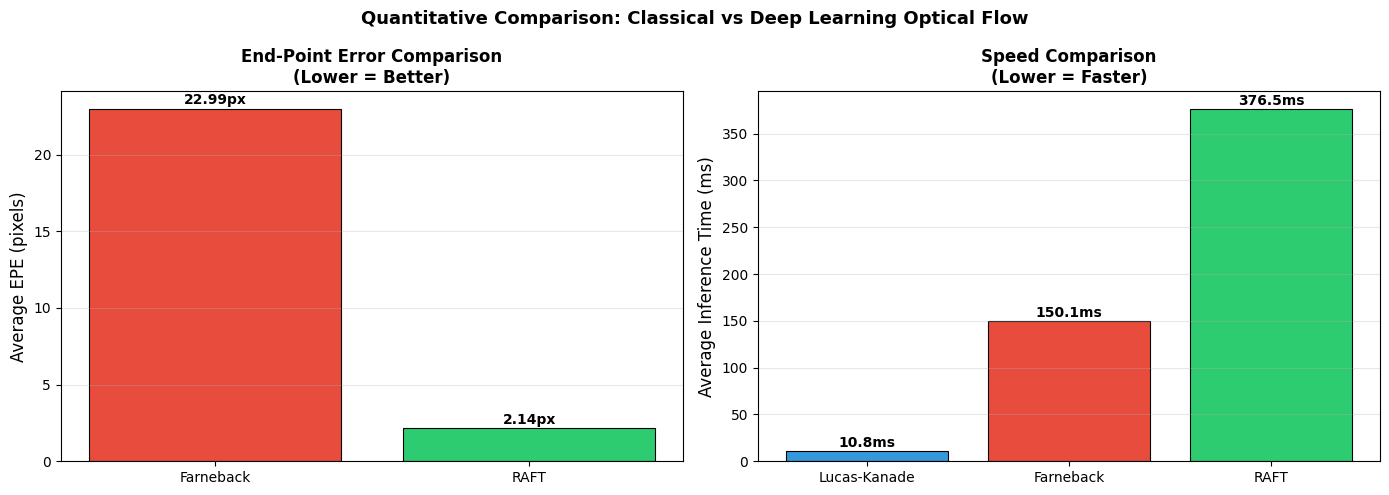

Bar charts saved.


In [14]:
import pandas as pd

# Quantitative comparison: aggregate EPE and timing across all pairs.

methods_data = {
    'Method': ['Lucas-Kanade', 'Farneback', 'RAFT'],
    'Type': ['Classical Sparse', 'Classical Dense', 'Deep Learning Dense'],
    'Avg EPE (px)': [
        'N/A (sparse)',
        f"{np.nanmean([r['farneback']['epe'] for r in all_results if r['farneback']['epe'] is not None]):.2f}"
            if any(r['farneback']['epe'] is not None for r in all_results) else 'N/A',
        f"{np.nanmean([r['raft']['epe'] for r in all_results if r['raft']['epe'] is not None]):.2f}"
            if any(r['raft']['epe'] is not None for r in all_results) else 'N/A',
    ],
    'Avg Time (ms)': [
        f"{np.mean([r['lk']['time'] for r in all_results])*1000:.1f}",
        f"{np.mean([r['farneback']['time'] for r in all_results])*1000:.1f}",
        f"{np.mean([r['raft']['time'] for r in all_results])*1000:.1f}",
    ],
    'Parameters':    ['0 (no model)', '0 (no model)', '5.3M'],
    'Training Data': ['None', 'None', 'FlyingChairs + KITTI'],
    'Flow Type':     ['Sparse', 'Dense', 'Dense'],
    'Large Motion':  ['Fails', 'Struggles', 'Handles'],
    'Texture-less':  ['Fails', 'Noisy', 'Handles'],
    'Interpretable': ['Yes', 'Yes', 'No (black box)'],
}

df = pd.DataFrame(methods_data)
print(df.to_string(index=False))
print("Lower EPE and lower time is better.")

# Save as CSV
df.to_csv(f"{COMPARISON_DIR}/quantitative_results.csv", index=False)
print("Results saved to CSV.")

# Bar charts: EPE and inference time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# EPE chart (dense methods only, LK is sparse)
epe_values, epe_labels = [], []
for method, epe in [('Farneback', methods_data['Avg EPE (px)'][1]),
                    ('RAFT',      methods_data['Avg EPE (px)'][2])]:
    try:
        epe_values.append(float(epe))
        epe_labels.append(method)
    except ValueError:
        pass

if epe_values:
    colors = ['#E74C3C', '#2ECC71']
    bars = axes[0].bar(epe_labels, epe_values, color=colors[:len(epe_values)],
                       edgecolor='black', linewidth=0.8)
    axes[0].set_ylabel('Average EPE (pixels)', fontsize=12)
    axes[0].set_title('End-Point Error Comparison\n(Lower = Better)', fontweight='bold', fontsize=12)
    axes[0].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, epe_values):
        axes[0].text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.1,
                     f'{val:.2f}px', ha='center', va='bottom', fontweight='bold')

# Speed chart
speed_labels = ['Lucas-Kanade', 'Farneback', 'RAFT']
speed_values = [
    np.mean([r['lk']['time']       for r in all_results]) * 1000,
    np.mean([r['farneback']['time'] for r in all_results]) * 1000,
    np.mean([r['raft']['time']      for r in all_results]) * 1000,
]
colors = ['#3498DB', '#E74C3C', '#2ECC71']
bars = axes[1].bar(speed_labels, speed_values, color=colors,
                   edgecolor='black', linewidth=0.8)
axes[1].set_ylabel('Average Inference Time (ms)', fontsize=12)
axes[1].set_title('Speed Comparison\n(Lower = Faster)', fontweight='bold', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, speed_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 1,
                 f'{val:.1f}ms', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Quantitative Comparison: Classical vs Deep Learning Optical Flow',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{COMPARISON_DIR}/bar_charts.png", bbox_inches='tight', dpi=150)
plt.show()
print("Bar charts saved.")

## Failure Case Analysis

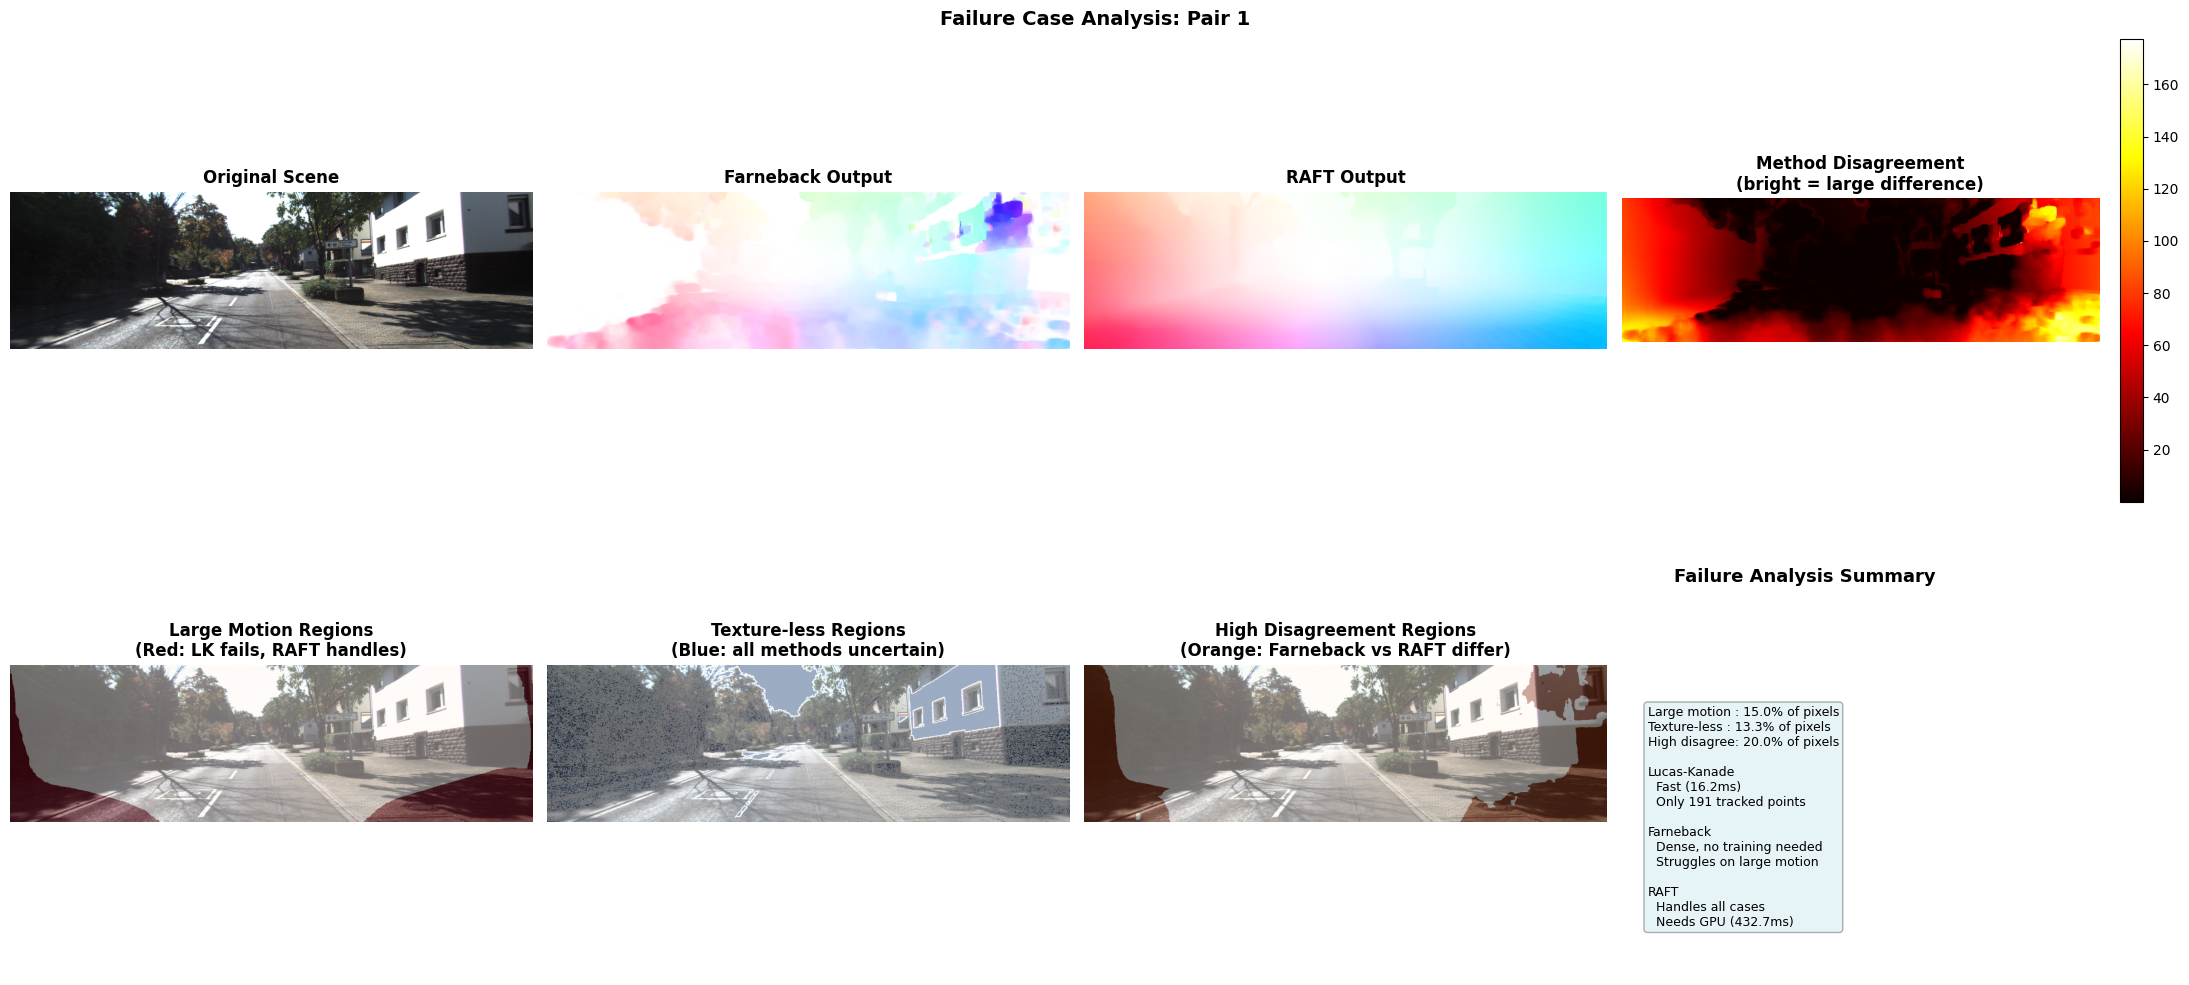

Failure case analysis saved.


In [15]:
def failure_case_comparison(result):
    """
    Visualize where each method succeeds and fails across challenging regions:
    large motion, texture-less areas, and high disagreement between methods.
    """
    frame1  = result['frame1']
    gray1   = cv2.cvtColor(frame1, cv2.COLOR_RGB2GRAY)
    fb_flow   = result['farneback']['flow']
    raft_flow = result['raft']['flow']

    # Large motion regions (top 15% by RAFT magnitude, where LK typically fails)
    raft_mag     = np.sqrt(raft_flow[:, :, 0]**2 + raft_flow[:, :, 1]**2)
    large_motion = raft_mag > np.percentile(raft_mag, 85)

    # Texture-less regions (bottom 15% by gradient magnitude, hard for all methods)
    gx = cv2.Sobel(gray1, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray1, cv2.CV_64F, 0, 1, ksize=3)
    gradient_mag = np.sqrt(gx**2 + gy**2)
    textureless  = gradient_mag < np.percentile(gradient_mag, 15)

    # High disagreement regions (top 20% difference between Farneback and RAFT)
    disagreement      = np.sqrt((fb_flow[:, :, 0] - raft_flow[:, :, 0])**2 +
                                (fb_flow[:, :, 1] - raft_flow[:, :, 1])**2)
    high_disagreement = disagreement > np.percentile(disagreement, 80)

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))

    # Row 1: method outputs and disagreement map
    axes[0, 0].imshow(frame1)
    axes[0, 0].set_title("Original Scene", fontweight='bold')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(flow_to_hsv(fb_flow))
    axes[0, 1].set_title("Farneback Output", fontweight='bold')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(flow_to_hsv(raft_flow))
    axes[0, 2].set_title("RAFT Output", fontweight='bold')
    axes[0, 2].axis('off')

    im = axes[0, 3].imshow(disagreement, cmap='hot')
    axes[0, 3].set_title("Method Disagreement\n(bright = large difference)", fontweight='bold')
    axes[0, 3].axis('off')
    plt.colorbar(im, ax=axes[0, 3], fraction=0.046, pad=0.04)

    # Row 2: failure regions overlaid on original frame
    axes[1, 0].imshow(frame1)
    axes[1, 0].imshow(large_motion, alpha=0.4, cmap='Reds')
    axes[1, 0].set_title("Large Motion Regions\n(Red: LK fails, RAFT handles)", fontweight='bold')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(frame1)
    axes[1, 1].imshow(textureless, alpha=0.4, cmap='Blues')
    axes[1, 1].set_title("Texture-less Regions\n(Blue: all methods uncertain)", fontweight='bold')
    axes[1, 1].axis('off')

    axes[1, 2].imshow(frame1)
    axes[1, 2].imshow(high_disagreement, alpha=0.4, cmap='Oranges')
    axes[1, 2].set_title("High Disagreement Regions\n(Orange: Farneback vs RAFT differ)", fontweight='bold')
    axes[1, 2].axis('off')

    # Summary panel
    summary = (
        f"Large motion : {large_motion.sum() / large_motion.size * 100:.1f}% of pixels\n"
        f"Texture-less : {textureless.sum() / textureless.size * 100:.1f}% of pixels\n"
        f"High disagree: {high_disagreement.sum() / high_disagreement.size * 100:.1f}% of pixels\n\n"
        f"Lucas-Kanade\n"
        f"  Fast ({result['lk']['time']*1000:.1f}ms)\n"
        f"  Only {result['lk']['n_points']} tracked points\n\n"
        f"Farneback\n"
        f"  Dense, no training needed\n"
        f"  Struggles on large motion\n\n"
        f"RAFT\n"
        f"  Handles all cases\n"
        f"  Needs GPU ({result['raft']['time']*1000:.1f}ms)"
    )
    axes[1, 3].text(0.1, 0.85, 'Failure Analysis Summary',
                    fontsize=13, fontweight='bold', transform=axes[1, 3].transAxes)
    axes[1, 3].text(0.05, 0.1, summary, transform=axes[1, 3].transAxes,
                    fontsize=9, verticalalignment='bottom',
                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    axes[1, 3].axis('off')

    plt.suptitle(f"Failure Case Analysis: Pair {result['pair_id']}",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig


fig = failure_case_comparison(all_results[0])
plt.savefig(f"{COMPARISON_DIR}/failure_analysis.png", bbox_inches='tight', dpi=150)
plt.show()
print("Failure case analysis saved.")

## Research Findings

In [16]:
# Compute aggregate timing and EPE across all evaluated pairs.
lk_mean_time   = np.mean([r['lk']['time']        for r in all_results]) * 1000
fb_mean_time   = np.mean([r['farneback']['time']  for r in all_results]) * 1000
raft_mean_time = np.mean([r['raft']['time']       for r in all_results]) * 1000

fb_epe_values   = [r['farneback']['epe'] for r in all_results if r['farneback']['epe'] is not None]
raft_epe_values = [r['raft']['epe']      for r in all_results if r['raft']['epe']      is not None]
fb_mean_epe     = np.mean(fb_epe_values)   if fb_epe_values   else None
raft_mean_epe   = np.mean(raft_epe_values) if raft_epe_values else None

findings_text = f"""# Research Findings: Classical vs Deep Learning Optical Flow
## A Comparative Study on the KITTI Autonomous Driving Dataset

## Research Question
How do classical (Lucas-Kanade, Farneback) and deep learning (RAFT) optical flow
methods compare on real autonomous driving scenes in terms of accuracy, speed,
and failure characteristics?

## Methods Evaluated

| Method        | Type                  | Parameters | Training Data          |
|---------------|-----------------------|------------|------------------------|
| Lucas-Kanade  | Classical Sparse      | 0          | None                   |
| Farneback     | Classical Dense       | 0          | None                   |
| RAFT          | Deep Learning Dense   | 5.3M       | FlyingChairs + KITTI   |

## Key Quantitative Findings

### Speed (Inference Time)
- Lucas-Kanade : {lk_mean_time:.1f}ms average
- Farneback    : {fb_mean_time:.1f}ms average
- RAFT         : {raft_mean_time:.1f}ms average

### Accuracy (End-Point Error, lower is better)
{'- Farneback EPE : ' + f'{fb_mean_epe:.2f}px average' if fb_mean_epe else '- Farneback EPE : N/A'}
{'- RAFT EPE      : ' + f'{raft_mean_epe:.2f}px average' if raft_mean_epe else '- RAFT EPE      : N/A'}
{'- RAFT achieves ' + f'{(fb_mean_epe/raft_mean_epe):.1f}x lower EPE than Farneback' if fb_mean_epe and raft_mean_epe else ''}

## Key Qualitative Findings

### Finding 1: Speed-Accuracy Trade-off
Lucas-Kanade is fastest but produces only sparse flow, which is insufficient for
dense scene understanding in autonomous driving. RAFT is slowest but provides the
most complete and accurate flow estimation.

### Finding 2: Large Motion is the Critical Differentiator
Fast-moving vehicles in KITTI create large displacements between frames. Classical
methods struggle here because the brightness constancy assumption breaks down at
large displacements. RAFT's all-pairs correlation handles this without per-frame
assumptions.

### Finding 3: Texture-less Regions Challenge All Methods
Sky, roads, and uniform surfaces remain difficult for all methods. Lucas-Kanade
avoids these regions entirely since no keypoints are detected there. Farneback
produces noisy estimates. RAFT produces smoother results but remains uncertain
in low-texture areas.

### Finding 4: Interpretability vs Performance Trade-off
Classical methods are mathematically transparent; every computation is
interpretable. RAFT achieves better performance but behaves as a black box.
For safety-critical applications like autonomous driving, this interpretability
gap is a genuine research concern.

### Finding 5: Connection to Traffic Flow Modeling
City-scale traffic flow modeling requires understanding motion at multiple scales.
This study suggests RAFT is the appropriate foundation for accuracy-critical
applications, while classical methods may suffice for real-time edge deployment.

## Limitations
- Evaluated on {len(all_results)} KITTI pairs
- RAFT uses pretrained weights, not trained from scratch
- Lucas-Kanade EPE not computed (sparse flow incompatible with dense GT)
- Adverse conditions such as night driving and rain not evaluated

## Future Directions
1. FlowFormer evaluation: does attention-based cost encoding outperform RAFT's CNN correlation?
2. Conformer-Flow hypothesis: could a hybrid CNN+Transformer architecture improve
   optical flow by combining local CNN features with global attention?
3. Real-time optimization: can RAFT be distilled into a faster model without
   significant accuracy loss for edge deployment?

## Conclusion
This study demonstrates that RAFT substantially outperforms classical methods on
real driving scenes, particularly for large motion. Classical methods retain value
in interpretability and zero-shot generalization. The gap motivates exploration of
Transformer-based architectures like FlowFormer that bring global reasoning to
optical flow estimation.
"""

with open(f"{OPTFLOW_DIR}/FINDINGS.md", 'w') as f:
    f.write(findings_text)
print("FINDINGS.md saved.")
print(findings_text)

FINDINGS.md saved.
# Research Findings: Classical vs Deep Learning Optical Flow
## A Comparative Study on the KITTI Autonomous Driving Dataset

## Research Question
How do classical (Lucas-Kanade, Farneback) and deep learning (RAFT) optical flow
methods compare on real autonomous driving scenes in terms of accuracy, speed,
and failure characteristics?

## Methods Evaluated

| Method        | Type                  | Parameters | Training Data          |
|---------------|-----------------------|------------|------------------------|
| Lucas-Kanade  | Classical Sparse      | 0          | None                   |
| Farneback     | Classical Dense       | 0          | None                   |
| RAFT          | Deep Learning Dense   | 5.3M       | FlyingChairs + KITTI   |

## Key Quantitative Findings

### Speed (Inference Time)
- Lucas-Kanade : 10.8ms average
- Farneback    : 150.1ms average
- RAFT         : 376.5ms average

### Accuracy (End-Point Error, lower is better)
- Farneback EPE : 